# Vererbung in Python

## Was ist Vererbung?

__Vererbung__ (engl. Inheritance) ist ein fundamentales Konzept der objektorientierten Programmierung, das es ermöglicht, neue Klassen basierend auf bestehenden Klassen zu erstellen.

- Eine __Basisklasse__ (auch Elternklasse oder Superklasse) definiert gemeinsame Eigenschaften und Methoden.
- Eine __abgeleitete Klasse__ (auch Kindklasse oder Unterklasse) erbt diese Eigenschaften und Methoden und kann sie erweitern oder überschreiben.

### Warum ist Vererbung wichtig?

1. __Code-Wiederverwendung__: Gemeinsamer Code muss nur einmal geschrieben werden und kann in mehreren Klassen verwendet werden.
2. __Hierarchische Strukturierung__: Vererbung ermöglicht es, natürliche Hierarchien zu modellieren (z.B. Tiere → Säugetiere → Hunde).
3. __Erweiterbarkeit__: Bestehende Klassen können erweitert werden, ohne den ursprünglichen Code zu ändern.

### Relevanz in der Mathematik und Wissenschaft

- __Geometrie__: Geometrische Formen (Polygon → Dreieck, Viereck, etc.) haben gemeinsame Eigenschaften.
- __Numerische Methoden__: Verschiedene Lösungsverfahren können von einer gemeinsamen Basisklasse abgeleitet werden.
- __Datenstrukturen__: Spezialisierte Arrays oder Matrizen können von NumPy-Klassen erben und zusätzliche mathematische Funktionalität bieten.
- __Simulation__: Verschiedene physikalische Objekte können gemeinsame Eigenschaften (Position, Geschwindigkeit) erben.

## Syntax der Vererbung

Die Syntax zur Definition einer abgeleiteten Klasse in Python ist:

```python
class DerivedClass(BaseClass):
    # Erweiterungen und Überschreibungen
```

Die abgeleitete Klasse erbt automatisch alle Attribute und Methoden der Basisklasse.

- Wird eine Methode der Basisklasse in der abgeleiteten Klasse nochmals definiert, so spricht man von __Überschreiben__ (engl. Overriding).
    - In der abgeleiteten Klasse wird die Methode der Basisklasse durch die Methode der abgeleiteten Klasse ersetzt.
    - Die Methode der Basisklasse kann mit `super()` aufgerufen werden.

### Beispiel: Einfache Vererbung

In [3]:
class Animal:
    def __init__(self, name):
        self.name = name
    
    def speak(self):
        return f"{self.name} macht ein Geräusch"

class Dog(Animal):
    def speak(self):
        return f"{self.name} bellt: Wuff!"

class Cat(Animal):
    def speak(self):
        return f"{self.name} miaut: Miau!"

# Verwendung
animal = Animal("Tier")
dog = Dog("Bello")
cat = Cat("Minka")

print(animal.speak())
print(dog.speak())
print(cat.speak())

Tier macht ein Geräusch
Bello bellt: Wuff!
Minka miaut: Miau!


In diesem Beispiel:
- `Dog` und `Cat` erben von `Animal`
- Beide überschreiben die `speak()` Methode mit spezifischem Verhalten
- Das `name` Attribut wird von `Animal` geerbt und muss nicht neu definiert werden

### Aufruf der Methode der Basisklasse
Man kann noch immer erzwingen, dass die Methode der Basisklasse aufgerufen wird.


In [17]:
print(Animal.speak(dog))  # Erzwingt Aufruf der Methode der Basisklasse
print(Animal.speak(cat))  # Erzwingt Aufruf der Methode der Basisklasse 
print(dog.speak())  # Ruft die Methode der abgeleiteten Klasse auf
print(cat.speak())  # Ruft die Methode der abgeleiteten Klasse auf

Bello macht ein Geräusch
Minka macht ein Geräusch
Bello bellt: Wuff!
Minka miaut: Miau!


## Die `super()` Funktion

Die `super()` Funktion ermöglicht es, Methoden der Basisklasse aus der abgeleiteten Klasse aufzurufen. Dies ist besonders nützlich, wenn:
- Der Konstruktor der Basisklasse aufgerufen werden soll
- Eine Methode erweitert (nicht vollständig überschrieben) werden soll

Syntax:
```python
super().__init__(parameters)  # Konstruktor der Basisklasse
super().method_name(parameters)  # Methode der Basisklasse
```

### Beispiel: Verwendung von `super()`
In diesem Beispiel wird der Konstruktor der Basisklasse aufgerufen um `brand` und `model` zu initialisieren, bevor das neue Attribut `num_doors` hinzugefügt wird.

In [4]:
class Vehicle:
    def __init__(self, brand, model):
        self.brand = brand
        self.model = model
    
    def info(self):
        return f"{self.brand} {self.model}"

class Car(Vehicle):
    def __init__(self, brand, model, num_doors):
        super().__init__(brand, model)  # Ruft Konstruktor der Basisklasse auf
        self.num_doors = num_doors      # Neues Attribut hinzufügen
    
    def info(self):
        base_info = super().info()  # Ruft Methode der Basisklasse auf
        return f"{base_info} mit {self.num_doors} Türen"

car = Car("VW", "Golf", 5)
print(car.info())
print(Vehicle.info(car))

VW Golf mit 5 Türen
VW Golf


## Praktisches Beispiel: Geometrische Formen

Geometrische Formen sind ein klassisches Beispiel für Vererbung. Wir definieren eine Basisklasse `Shape` und leiten daraus verschiedene spezifische Formen ab.
- Oft dient die Basisklasse nur als Bauplan und gibt nur Methoden vor die später implementiert werden müssen (abstrakte Klasse).
    - `NotImplementedError` wird ausgelöst um das zu signalisieren.

In [19]:
class Shape:
    """Basisklasse für geometrische Formen"""
    def __init__(self, name):
        self.name = name
    
    def area(self):
        raise NotImplementedError("Unterklassen müssen die area() Methode implementieren")
    
    def perimeter(self):
        raise NotImplementedError("Unterklassen müssen die perimeter() Methode implementieren")
    
    def describe(self):
        return f"{self.name}: Fläche = {self.area():.2f}, Umfang = {self.perimeter():.2f}"

class Rectangle(Shape):
    """Rechteck als Unterklasse von Shape"""
    def __init__(self, width, height):
        super().__init__("Rechteck")
        self.width = width
        self.height = height
    
    def area(self):
        return self.width * self.height
    
    def perimeter(self):
        return 2 * (self.width + self.height)

class Circle(Shape):
    """Kreis als Unterklasse von Shape"""
    def __init__(self, radius):
        super().__init__("Kreis")
        self.radius = radius
    
    def area(self):
        return 3.14159 * self.radius ** 2
    
    def perimeter(self):
        return 2 * 3.14159 * self.radius

class Triangle(Shape):
    """Dreieck als Unterklasse von Shape"""
    def __init__(self, a, b, c):
        super().__init__("Dreieck")
        self.a = a
        self.b = b
        self.c = c
    
    def area(self):
        # Heronsche Formel
        s = self.perimeter() / 2
        return (s * (s - self.a) * (s - self.b) * (s - self.c)) ** 0.5
    
    def perimeter(self):
        return self.a + self.b + self.c

# Verwendung
shapes = [
    Rectangle(4, 5),
    Circle(3),
    Triangle(3, 4, 5)
]

for shape in shapes:
    print(shape.describe())

Rechteck: Fläche = 20.00, Umfang = 18.00
Kreis: Fläche = 28.27, Umfang = 18.85
Dreieck: Fläche = 6.00, Umfang = 12.00


Dieses Beispiel zeigt:
- __Gemeinsame Schnittstelle__: Alle Formen haben `area()` und `perimeter()` Methoden
- __Code-Wiederverwendung__: Die `describe()` Methode wird nur einmal in der Basisklasse definiert
- __Polymorphismus__: Wir können verschiedene Formen in einer Liste speichern und einheitlich behandeln
- __Erweiterbarkeit__: Neue Formen können einfach hinzugefügt werden, ohne bestehenden Code zu ändern

## Erweiterte Vererbungshierarchie

Vererbung kann über mehrere Ebenen erfolgen. Wir erweitern unser Beispiel mit einer Spezialisierung:

In [20]:
class Square(Rectangle):
    """Quadrat als Spezialfall des Rechtecks"""
    def __init__(self, side):
        super().__init__(side, side)  # Ruft Rectangle-Konstruktor auf
        self.name = "Quadrat"
        self.side = side
    
    def diagonal(self):
        """Zusätzliche Methode für Quadrate"""
        return self.side * (2 ** 0.5)
    
    def describe(self):
        base_desc = super().describe()
        return f"{base_desc}, Diagonale = {self.diagonal():.2f}"

square = Square(4)
print(square.describe())

Quadrat: Fläche = 16.00, Umfang = 16.00, Diagonale = 5.66


Hier erbt `Square` von `Rectangle`, das wiederum von `Shape` erbt. Das Quadrat:
- Nutzt die Implementierung des Rechtecks für Fläche und Umfang
- Fügt eine zusätzliche `diagonal()` Methode hinzu
- Erweitert die `describe()` Methode

## Vererbung und Statische Attribute
- Statische Attribute der Basisklasse sind von abgeleiteten Klassen zugänglich.
    - Python sucht zuerst in der Instanz (falls man über eine Instanz darauf zugreift), dann in der Klasse und schließlich in der Basisklasse nach dem Attribut.
    - Änderungen an einem statischen Attribut in der Basisklasse wirken sich auf alle abgeleiteten Klassen aus, sofern diese das Attribut nicht überschreiben.
- Wenn man in der abgeleiteten Klasse ein statisches Attribut ändert, passiert dies nur für diese Klasse und nicht für die Basisklasse oder andere abgeleitete Klassen.
    - Der Grund ist, dass Python das Attribut in der abgeleiteten Klassen nicht findet und es daher in der abgeleiteten Klasse neu anlegt.
    - Das Attribut der Basisklasse (mit dem gleichen Namen) wird verdeckt.


In [21]:
class A:
    a = 10  # Statisches Attribut der Basisklasse
class B(A):
    def __init__(self):
        self.b = 20 # Instanzattribut der abgeleiteten Klasse, unwichtig für das Beispiel
class C(A):
    def __init__(self):
        self.c = 30 # Instanzattribut der abgeleiteten Klasse, unwichtig für das Beispiel


print(f"A.a = {A.a}, B.a = {B.a}, C.a = {C.a}")
B.a = 30  # Erstellt ein neues statisches Attribut für die Klasse B, verdeckt aber das Attribut der Basisklasse A
print(f"A.a = {A.a}, B.a = {B.a}, C.a = {C.a}")
A.a = 40  # Überschreibt das statische Attribut für die Instanz A und damit auch für C, da C das Attribut von A erbt
print(f"A.a = {A.a}, B.a = {B.a}, C.a = {C.a}")

A.a = 10, B.a = 10, C.a = 10
A.a = 10, B.a = 30, C.a = 10
A.a = 40, B.a = 30, C.a = 40


## Subclassing von existierenden Klassen

Python erlaubt es, von manchen externen Klassen zu erben, um spezialisierte Funktionalität zu implementieren.

### Die `__new__` und `__del__` Methoden
Die `__new__` Methode ist eine weitere magische Methode in Python, die für die Erstellung einer neuen Instanz einer Klasse verantwortlich ist. Sie wird aufgerufen, bevor der Konstruktor `__init__` ausgeführt wird und gibt ein neues Objekt der Klasse zurück. 

Die `__del__` Methode wird aufgerufen, wenn eine Instanz der Klasse gelöscht wird. Sie kann verwendet werden, um Aufräumarbeiten durchzuführen, bevor das Objekt aus dem Speicher entfernt wird. Üblicherweise wird `__del__` aufgerufen, wenn keine Variable mehr auf das Objekt verweist. Da Python eine automatische Speicherbereinigung (Garbage Collection) verwendet, ist die Verwendung von `__del__` in der Praxis eher selten.

Syntax:
```python
def __new__(cls, *args, **kwargs):
    # Erstellen und Rückgabe einer neuen Instanz
    return #new_instance

def __del__(self):
    # Aufräumarbeiten vor der Löschung der Instanz
```

In [22]:
class Test():
    def __new__(cls):
        print("Creating instance")
        instance = super().__new__(cls)
        return instance
    def __init__(self):
        print("Initializing instance")
        self.value = 0
    def __del__(self):
        print("Deleting instance")

# Create instance of Test
test = Test()
# Let variable test point to something else, triggering __del__ since no reference to instance of Test remains
test = 5.0

Creating instance
Initializing instance
Deleting instance


### Verwendung von `__new__` um von unveränderlichen Typen zu erben
Die `__new__` Methode wird besonders wichtig, wenn man von unveränderlichen Typen wie `int`, `str` oder `tuple` erben möchte. Da diese Typen nicht verändert werden können, muss die `__new__` Methode verwendet werden, um eine neue Instanz zu erstellen.

In [23]:
class UnitFloat(float):
    def __new__(cls,value, unit):
        instance = super().__new__(cls,value)
        instance.unit = unit
        return instance
    
    def __str__(self):
        return str(self.real)+" "+self.unit
    
    def __add__(self, other):
        if isinstance(other, UnitFloat) and self.unit != other.unit:
            raise ValueError(f"Cannot add {self.unit} and {other.unit}")
        return UnitFloat(super().__add__(other), self.unit)
    
    def __truediv__(self, other):
        if isinstance(other, UnitFloat):
            return UnitFloat(super().__truediv__(other), f"{self.unit}/{other.unit}")
        return UnitFloat(super().__truediv__(other), self.unit)
    
    def __mul__(self, other):
        return UnitFloat(super().__mul__(other), f"{self.unit}")
    
    __rmul__ = __mul__
    

length = UnitFloat(42.195,"km")
time = UnitFloat(2.0, "hours")
print(f"A Marathon is {length} and the world record is just above {time}")
print(f"The average speed is {length/time}")
print(f"A quarter-marathon is {length/4}")


A Marathon is 42.195 km and the world record is just above 2.0 hours
The average speed is 21.0975 km/hours
A quarter-marathon is 10.54875 km


### Rückblick `view()`
Zur Erinnerung: Die `view()` Methode in NumPy erstellt eine neue Ansicht (View) eines Arrays mit einem anderen Datentyp oder einer anderen Klasse, ohne die zugrunde liegenden Daten zu kopieren.
- `view()` hat einen Parameter `type`, der es ermöglicht, den View als eine benutzerdefinierte Klasse zu interpretieren, die von `ndarray` erbt.


### NumPy-Klassen erweitern?
Ein nützliches Beispiel ist, die `ndarray` Klasse zu erweitern, um spezialisierte Array-Typen mit zusätzlicher Funktionalität zu erstellen. 

1. __Domänenspezifische Operationen__: Zusätzliche mathematische Operationen, die für spezielle Anwendungen relevant sind
2. __Validierung__: Automatische Überprüfung von Daten (z.B. nur positive Werte, normalisierte Vektoren)
3. __Metadaten__: Zusätzliche Informationen zu den Daten (z.B. Einheiten, Namen)
4. __Benutzerdefiniertes Verhalten__: Spezielle Darstellung oder Operationen für wissenschaftliche Anwendungen

### Beispiel: Vektor-Klasse mit zusätzlichen Methoden

Wir erweitern die `ndarray` Klasse, um eine `Vector` Klasse zu erstellen, die zusätzliche Methoden für Vektorrechnung bietet.
- `norm`: Berechnet die euklidische Norm des Vektors $|v|^2 = v_1^2 + v_2^2 + ... + v_d^2$
- `angle_with`: Berechnet den Winkel $\theta$ zwischen zwei Vektoren $v$ und $w$ mit der Formel
$$
    \cos(\theta) = \frac{v \cdot w}{|v| \cdot |w|}
$$

In [24]:
import numpy as np

class Vector(np.ndarray):
    """Erweiterte Vektor-Klasse mit zusätzlichen mathematischen Operationen"""
    
    def __new__(cls, input_array):
        # Input array wird in ndarray konvertiert und als Vector behandelt
        obj = np.array(input_array).view(type=cls)
        return obj
    
    def norm(self):
        """Berechnet die euklidische Norm (Länge) des Vektors"""
        return np.sqrt(np.sum(self ** 2))
    
    def normalize(self):
        """Gibt einen normalisierten Vektor (Länge 1) zurück"""
        n = self.norm()
        if n == 0:
            raise ValueError("Kann Nullvektor nicht normalisieren")
        return Vector(self / n)
    
    def angle_with(self, other):
        """Berechnet den Winkel (in Grad) zwischen diesem und einem anderen Vektor"""
        dot_product = np.dot(self, other)
        cos_angle = dot_product / (self.norm() * Vector(other).norm())
        # Numerische Stabilität: cos_angle kann durch Rundungsfehler außerhalb [-1, 1] liegen
        cos_angle = np.clip(cos_angle, -1.0, 1.0)
        angle_rad = np.arccos(cos_angle)
        return np.degrees(angle_rad)
    
    def is_orthogonal_to(self, other, tolerance=1e-10):
        """Prüft, ob dieser Vektor orthogonal zu einem anderen ist"""
        return abs(np.dot(self, other)/ (self.norm() * Vector(other).norm())) < tolerance

# Verwendung
v1 = Vector([3, 4])
v2 = Vector([4, -3])
v3 = Vector([1, 0])

print(f"Vektor v1: {v1}")
print(f"Länge von v1: {v1.norm():.2f}")
print(f"Normalisierter v1: {v1.normalize()}")
print(f"Winkel zwischen v1 und v2: {v1.angle_with(v2):.2f}°")
print(f"Sind v1 und v2 orthogonal? {v1.is_orthogonal_to(v2)}")
print(f"Winkel zwischen v1 und v3: {v1.angle_with(v3):.2f}°")

Vektor v1: [3 4]
Länge von v1: 5.00
Normalisierter v1: [0.6 0.8]
Winkel zwischen v1 und v2: 90.00°
Sind v1 und v2 orthogonal? True
Winkel zwischen v1 und v3: 53.13°


In diesem Beispiel:
- Die `Vector` Klasse erbt von `np.ndarray`
- `__new__` wird verwendet (statt `__init__`), da NumPy Arrays unveränderliche Größe haben
- Zusätzliche Methoden wie `norm()`, `normalize()`, `angle_with()` und `is_orthogonal_to()` werden hinzugefügt
- Alle Standard-NumPy-Operationen funktionieren weiterhin (Addition, Multiplikation, etc.)

### Beispiel: Fast orthogonale Vektoren finden

In $\mathbb{R}^d$ können höchstens $d$ orthogonale Vektoren existieren. Wir können jedoch versuchen, eine größere Menge von Vektoren zu finden, die "fast" orthogonal zueinander sind, indem wir eine Toleranz für den Winkel zwischen den Vektoren zulassen. 

Eine gute Methode ist, zufällige Vektoren zu generieren und zu überprüfen, ob sie innerhalb der Toleranz orthogonal zu den bereits ausgewählten Vektoren sind. Wenn ja, fügen wir sie zur Menge hinzu. Dabei verwenden wir `randn()` um normalverteilte Zufallszahlen zu generieren, was in höheren Dimensionen oft zu besser verteilten Vektoren führt.

Es wurden 30 fast orthogonale Vektoren gefunden:


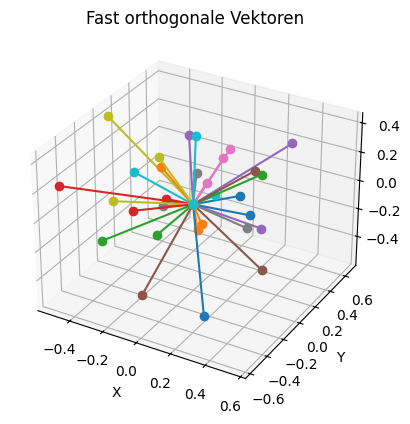

In [25]:
import matplotlib.pyplot as plt
def find_almost_orthogonal_set(dim, tolerance, max_attempts=1000):
    """Findet eine Menge von fast orthogonalen Vektoren in einem gegebenen Raum"""
    vectors = []
    for _ in range(max_attempts):
        candidate = Vector(np.random.randn(dim))
        candidate = candidate.normalize()
        if all(candidate.is_orthogonal_to(v, tolerance) for v in vectors):
            vectors.append(candidate)
    return vectors

vectors = find_almost_orthogonal_set(10, tolerance=0.5)
print(f"Es wurden {len(vectors)} fast orthogonale Vektoren gefunden:")

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each vector
for vector in vectors:
    ax.plot([0, vector[0]], [0, vector[1]], [0, vector[2]], marker='o')

# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Fast orthogonale Vektoren')

plt.show()

### Beispiel: Klasse für sortierte Vektoren
Durch Subclassing können wir erzwingen, dass die Elemente eines Vektors immer sortiert sind.

In [26]:
class SortedVector(np.ndarray):
    """Vektor-Klasse, die ihre Elemente immer sortiert hält"""
    
    def __new__(cls, input_array):
        obj = np.array(input_array).view(type=cls)
        obj.sort()  # Sortiere die Elemente beim Erstellen
        return obj
    
    def append(self, value):
        """Fügt ein Element hinzu und hält den Vektor sortiert"""
        new_array = np.append(self, value)
        new_array.sort()
        return SortedVector(new_array)
    
    def __setitem__(self, key, value):
        """Setzt ein Element und hält den Vektor sortiert"""
        super().__setitem__(key, value)
        self.sort()

x = SortedVector([3, 1, 4])
print(x)  # Ausgabe: [1 3 4]
x = x.append(2)
print(x)  # Ausgabe: [1 2 3 4]
x[0] = 5
print(x)  # Ausgabe: [2 3 4 5]

[1 3 4]
[1 2 3 4]
[2 3 4 5]


## Beispiel: Eine Klasse für die numerische Lösung von Gleichungen
Wir kennen bereits die Bisektionsmethode um Nullstellen von Funktionen zu finden. Um Gleichungen der Art

$$
f(x) = y 
$$

zu lösen, suchen wir einfach eine Nullstelle der Funktion $g(x) = f(x) - y$.
Will man die Gleichung mehrmals für verschiedene Werte von $y$ lösen, so ist es sinnvoll, eine Klasse zu erstellen, die die Funktion $f$ und die Methode zur Nullstellensuche kapselt.
- Die Klasse speichert vergangene Lösungen, um wiederholte Berechnungen zu vermeiden.
- Dabei wird überprüft, ob die rechte Seite $y$ bis auf eine gewisse Toleranz bereits in einer Liste von vergangenen rechten Seiten vorkommt.
    - Wenn ja, wird die zugehörige, gepeicherte Lösung zurückgegeben.
    - Wenn nein, wird die Bisektionsmethode angewendet und die neue Lösung gespeichert.

In [29]:
import numpy as np
class Solver:
    def __init__(self, func):
        self.func = func
        self.past_solutions = np.array([])   # Array zur Speicherung vergangener Lösungen
        self.past_rhs = np.array([])  # Array zur Speicherung vergangener rechten Seiten (right-hand sides - rhs)

    # Prüft, ob die rechte Seite bereits gelöst wurde
    def check_rhs(self, rhs, tol=1e-7):
        mask = np.abs(self.past_rhs - rhs) < tol
        if np.any(mask):
            return self.past_solutions[mask][0]  # Rückgabe der gespeicherten Lösung
        return None
    # Fügt eine neue Lösung und die zugehörige rechte Seite hinzu
    def add_solution(self, rhs, solution):
        self.past_solutions = np.append(self.past_solutions, solution)
        self.past_rhs = np.append(self.past_rhs, rhs)
    # Löst die Gleichung func(x) = rhs im Intervall [a, b] mit Bisection-Methode
    def solve(self, rhs, a, b, tol=1e-7, max_iter=100):        
        solution = self.check_rhs(rhs, tol)
        if solution is not None:
            return solution, 0  # Rückgabe der gespeicherten Lösung und 0 Iterationen
        func = lambda x: self.func(x) - rhs
        root, iterations = self.bisection(func, a, b, tol, max_iter)
        self.add_solution(rhs, root)
        return root, iterations
    # Bisection-Methode zur Nullstellenfindung
    def bisection(self, func, a, b, tol, max_iter):
        if func(a) * func(b) >= 0:
            raise ValueError("f(a) und f(b) müssen unterschiedliche Vorzeichen haben.")
        for j in range(max_iter):
            c = (a + b) / 2
            f_c = func(c)            
            if abs(f_c) < tol or (b - a) / 2 < tol:
                return c, j+1  # Rückgabe der Nullstelle und der Anzahl der Iterationen
            if func(a) * f_c < 0:
                b = c
            else:
                a = c
        raise ValueError("Maximale Iterationen erreicht. Keine Lösung gefunden.")
    
# Beispielverwendung
func = lambda x: x**3 - x - 2
solve = Solver(func)
root1, iterations = solve.solve(0, 1, 3)
print(f"Die Lösung von x^3-x-2 = 0 ist: {root1:.7f} (gefunden in {iterations} Iterationen)")
root2, iterations = solve.solve(3, 1, 3)
print(f"Die Lösung von x^3-x-2 = 3 ist: {root2:.7f} (gefunden in {iterations} Iterationen)")
root1, iterations = solve.solve(0, 1, 3)
print(f"Die Lösung von x^3-x-2 = 0 ist: {root1:.7f} (gefunden in {iterations} Iterationen)")

Die Lösung von x^3-x-2 = 0 ist: 1.5213797 (gefunden in 23 Iterationen)
Die Lösung von x^3-x-2 = 3 ist: 1.9041609 (gefunden in 24 Iterationen)
Die Lösung von x^3-x-2 = 0 ist: 1.5213797 (gefunden in 0 Iterationen)


Wir testen die Implementierung indem wir die Funktion und die errechneten Nullstellen plotten.

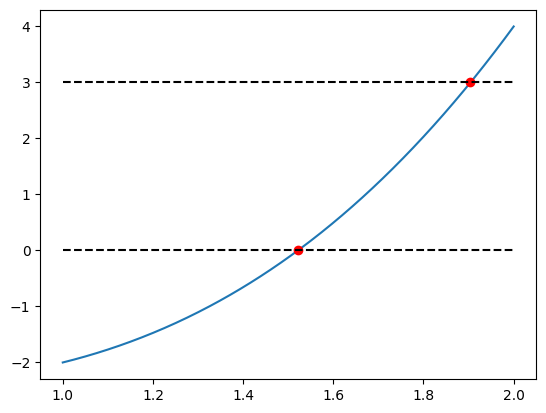

In [ ]:
import matplotlib.pyplot as plt
x_vals = np.linspace(1, 2, 400)
y_vals = func(x_vals)
plt.plot(x_vals, y_vals, label='f(x)')
plt.plot([root1, root2], [0, 3], 'ro')
plt.plot([1,2], [0,0], 'k--')
plt.plot([1,2], [3,3], 'k--')
plt.show()

### Erweiterung der Klasse um die Newton Methode
Wenn die Funktion $f$ differenzierbar ist (also wenn die Ableitung $f'$ existiert), so kann die Newton Methode verwendet werden, um Nullstellen zu finden. Diese Methode konvergiert in der Regel schneller als die Bisektionsmethode, erfordert jedoch eine Anfangsnäherung und die Berechnung der Ableitung.
- Die Berechnungsvorschrift der Newton Methode lautet:
$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$
- Wenn die Newton Methode konvergiert, so verdoppelt sich die Anzahl der korrekten Nachkommastellen in jedem Schritt.
- Beim Bisektionsverfahren hingegen erhöht sich die Anzahl der korrekten Nachkommastellen etwa alle 3 bis 4 Schritte um eine.
- Die Newton Methode ist empfindlich gegenüber der Wahl des Startwerts und kann fehlschlagen, wenn die Ableitung nahe null ist oder wenn der Startwert weit von der tatsächlichen Nullstelle entfernt ist.
- In diesem Fall ruft die Klasse die robustere Bisektionsmethode auf.

In [ ]:
class NewtonSolver(Solver):
    def __init__(self, func, dfunc):
        super().__init__(func)
        self.dfunc = dfunc  # Ableitungsfunktion

    def solve(self, rhs, a, b, tol=1e-7, max_iter=100):        
        solution = self.check_rhs(rhs, tol)
        if solution is not None:
            return solution, 0  # Rückgabe der gespeicherten Lösung und 0 Iterationen
        func = lambda x: self.func(x) - rhs
        root, iterations = self.newton(func, a, b, 0.5*(a+b), tol, max_iter)
        if root is None:
            print("Newton Method failed, trying bisection instead...")
            root, iterations = self.bisection(func, a, b, tol, max_iter)
        self.add_solution(rhs, root)
        return root, iterations
    
    def newton(self, func, a, b, x0, tol, max_iter):
        x = x0
        for j in range(max_iter):
            f_x = func(x)
            d_f_x = self.dfunc(x)
            if abs(f_x) < tol:
                return x, j+1  # Rückgabe der Nullstelle und der Anzahl der Iterationen
            if abs(d_f_x) < 1e-12:
                return None, j+1
            x -= f_x / d_f_x
            if x < a or x > b:
                return None, j+1
        return None, max_iter
    
    
solve = NewtonSolver(lambda x: x**3-x-2, lambda x: 3*x**2-1)
root, iterations = solve.solve(0, 1, 3)
print(f"Die Lösung von x^3-x-2 = 0 ist: {root:.7f} (gefunden in {iterations} Iterationen)")
root, iterations = solve.solve(3, 1, 3)
print(f"Die Lösung von x^3-x-2 = 3 ist: {root:.7f} (gefunden in {iterations} Iterationen)")
root, iterations = solve.solve(0, 1, 3)
print(f"Die Lösung von x^3-x-2 = 0 ist: {root:.7f} (gefunden in {iterations} Iterationen)")


Die Lösung von x^3-x-2 = 0 ist: 1.5213797 (gefunden in 5 Iterationen)
Die Lösung von x^3-x-2 = 3 ist: 1.9041609 (gefunden in 4 Iterationen)
Die Lösung von x^3-x-2 = 0 ist: 1.5213797 (gefunden in 0 Iterationen)


### Fehlschlagen der Newton Methode
Ein klassisches Beispiel, wo die Newton Methode fehlschlägt, ist die Funktion $f(x) = \arctan(x)$ mit der Ableitung $f'(x) = \frac{1}{1+x^2}$. 

In [ ]:
solve = NewtonSolver(lambda x: np.atan(x), lambda x: 1/(1+x**2))
root, iterations = solve.solve(0, -1, 5)
print(f"Die Lösung von arctan(x) = 0 ist: {root:.7f} (gefunden in {iterations} Iterationen)")

Newton Method failed, trying bisection instead...
Die Lösung von arctan(x) = 0 ist: -0.0000001 (gefunden in 25 Iterationen)


Um zu verstehen, warum die Newton Methode in diesem Fall fehlschlägt, plotten wir die Iterationen der Newton Methode.

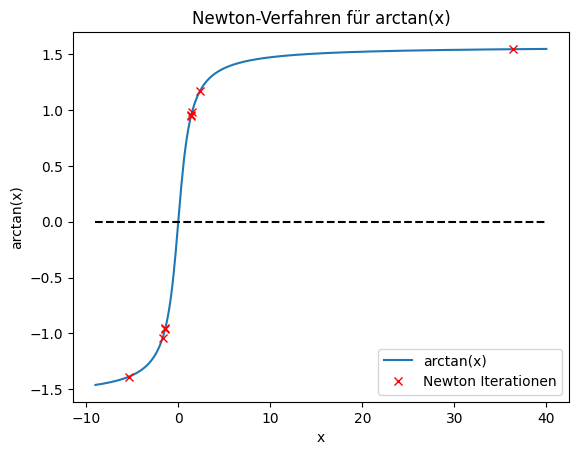

In [ ]:
def newton_plot(func, dfunc, a, b, x0, tol, max_iter):
        x = x0
        hist = np.array([x0])
        for j in range(max_iter):
            f_x = func(x)
            d_f_x = dfunc(x)
            if abs(f_x) < tol:
                return x, hist 
            if abs(d_f_x) < 1e-12:
                return None, j+1
            x -= f_x / d_f_x
            hist = np.append(hist, x)
            if x < a or x > b:
                return None, hist
        return None, hist

_, hist = newton_plot(lambda x: np.atan(x), lambda x: 1/(1+x**2), -100, 100, 1.394, 1e-7, 100)

hist = hist[:-1]
import matplotlib.pyplot as plt
x_vals = np.linspace(-9, 40, 400)
plt.plot(x_vals, np.arctan(x_vals), label='arctan(x)')
plt.plot(hist, np.arctan(np.array(hist)), 'rx', label='Newton Iterationen')
plt.plot([ -9, 40], [0, 0], 'k--')
plt.xlabel('x')
plt.ylabel('arctan(x)')
plt.title('Newton-Verfahren für arctan(x)')
plt.legend()
plt.show()